# Flag collection: training

Train Q-learning and SARSA independently, then inspect their saved plots and optional recordings. Parameters are editable below. Training starts only when `RUN_TRAINING=True`; running this notebook with its default flag creates no experiment artifacts. See [the section guide](README.md) for the task and output conventions.

In [15]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [16]:
from pathlib import Path
import sys
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "rl_project").is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from IPython.display import Image, Markdown, Video, display
from rl_project.runtime import video_sort_key
from rl_project.discrete import validate_algorithms
ALGORITHM_LABELS = {"qlearning": "Q-learning", "sarsa": "SARSA"}
from Grid_flag.grid_flag_env import GridFlagEnv
from Grid_flag.grid_flag_agent import GridFlagAgent

## Configuration

The agent collects five flags on a 10×10 grid. Collecting the final flag terminates immediately. The 100-step external cutoff stops the rollout while retaining the value bootstrap. Actions are 0=stay, 1=up, 2=down, 3=left, 4=right.

`config.json` is written automatically inside each new run as a snapshot of the settings used. Edit this notebook, not that saved snapshot. Shortening the episode budget does not automatically accelerate the exploration schedule.

In [17]:
ALGORITHMS = ("qlearning", "sarsa")  # Select both, or e.g. ("sarsa",).
RUN_TRAINING = False
SEED = 0
NUM_EPISODES = 5000  # Budget for each selected algorithm.
MAX_ENV_STEPS = None  # Optional per-algorithm step budget; use NUM_EPISODES=None for steps only.
OUTPUT_ROOT = ROOT / "artifacts"
RECORD_EVERY = 500  # Set None to disable demonstration recordings.
LOG_EVERY = 500
SHOW_PROGRESS = True

# One common task for both algorithms.
ENV_KWARGS = {
    "grid_size": (10, 10),
    "max_step": 100,
    "agent_start": (5, 5),
    "flag_value": 10,
    "flag_cells": [(1, 2), (3, 7), (6, 1), (7, 8), (9, 4)],
    "render_mode": None,
}

# Independent algorithm settings: changing one does not change the other.
AGENT_KWARGS = {
    "qlearning": {
        "learning_rate": .1,
        "discount_factor": .95,
        "initial_epsilon": 1.,
        "epsilon_decay": .95 / 5000,
        "final_epsilon": .05,
    },
    "sarsa": {
        "learning_rate": .1,
        "discount_factor": .95,
        "initial_epsilon": 1.,
        "epsilon_decay": .95 / 5000,
        "final_epsilon": .05,
    },
}

## Train

Each selected algorithm gets a fresh agent and a separate run directory. Checkpoints and incremental CSV metrics are saved before plotting. Q-learning uses a greedy backup; SARSA executes the same next action that was sampled for its backup.

The live total progress bar stays below summaries of each `LOG_EVERY` completed episodes, including a final partial block. Summary and recording labels start at episode 0; the total bar and CSV count completed episodes from 1.

In [18]:
agents = {}
results = {}
selected_algorithms = validate_algorithms(ALGORITHMS)
if RUN_TRAINING:
    for algorithm in selected_algorithms:
        display(Markdown(f"### {ALGORITHM_LABELS[algorithm]} training"))
        env = GridFlagEnv(**ENV_KWARGS)
        try:
            agent = GridFlagAgent(env, seed=SEED, environment="flag", **AGENT_KWARGS[algorithm])
            result = agent.train(
                NUM_EPISODES, algorithm=algorithm, max_env_steps=MAX_ENV_STEPS,
                output_root=OUTPUT_ROOT, record_every=RECORD_EVERY,
                log_every=LOG_EVERY, show_progress=SHOW_PROGRESS,
            )
            agents[algorithm] = agent
            results[algorithm] = result
            print(f"Saved run: {result.run_dir}")
        finally:
            env.close()
else:
    print("Training not run. Set RUN_TRAINING=True to start fresh runs; no checkpoint was loaded.")

Training not run. Set RUN_TRAINING=True to start fresh runs; no checkpoint was loaded.


## Inspect plots and recordings

Reward bands show rolling mean ± two rolling standard deviations within one run. Outcomes show rolling success rate and flags collected; binary success/collision indicators are omitted. TD error and epsilon are learning diagnostics.

With `RECORD_EVERY=500`, separate greedy demonstrations run after training episodes 0, 500, 1000, and so on, producing `episode_0.mp4`, `episode_500.mp4`, etc. Episode 0 is the first completed training episode. Videos are capped at 300 frames and 800 pixels wide; the demonstration still runs to the actual episode boundary.

In [19]:
for algorithm, result in results.items():
    display(Markdown(f"### {ALGORITHM_LABELS[algorithm]} outputs"))
    for path in sorted((result.run_dir / "plots").glob("*.png")):
        display(Image(filename=str(path)))
    for path in sorted((result.run_dir / "videos/training").glob("*.mp4"), key=video_sort_key):
        display(Markdown(f"**{path.name}**"))
        display(Video(filename=str(path), embed=True))

## Evaluation and report export

Open [eval_grid_flag.ipynb](eval_grid_flag.ipynb) to evaluate selected checkpoints greedily and save presentation recordings.

For the report, review the completed runs and copy Q-learning `plots/training_curves.png` as `GridFlag_training_curves.png`, and the SARSA equivalent as `GridFlag_training_curves_SARSA.png`. Update the matching report analysis using the saved metrics. [The report figure inventory](../Report/figures/README.md) identifies the pending slots. This notebook does not replace report evidence automatically.

Q-learning: c:\Users\39324\Desktop\NAML_RL_gym\artifacts\flag\qlearning\20260913T085943978379Z_seed0_85399cae
SARSA: c:\Users\39324\Desktop\NAML_RL_gym\artifacts\flag\sarsa\20260913T085951982917Z_seed0_d34cfb8b


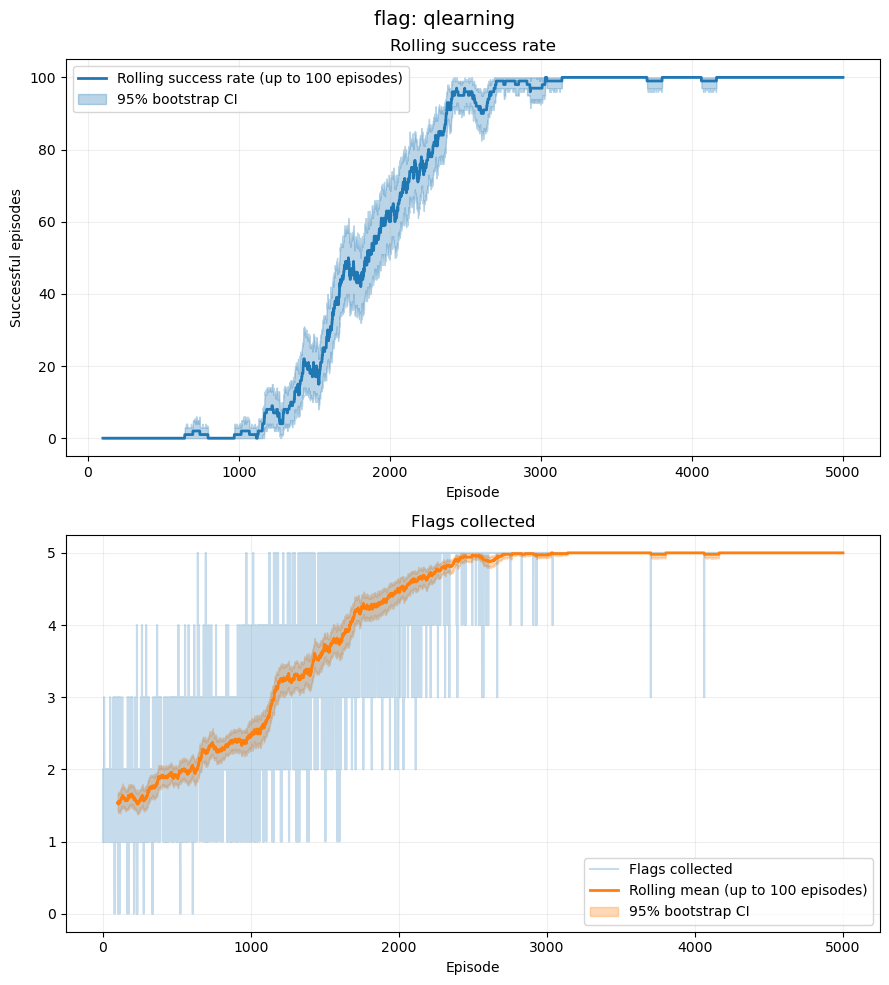

Salvato: c:\Users\39324\Desktop\NAML_RL_gym\artifacts\flag\bootstrap_plots\GridFlag_outcomes_qlearning_bootstrap.png


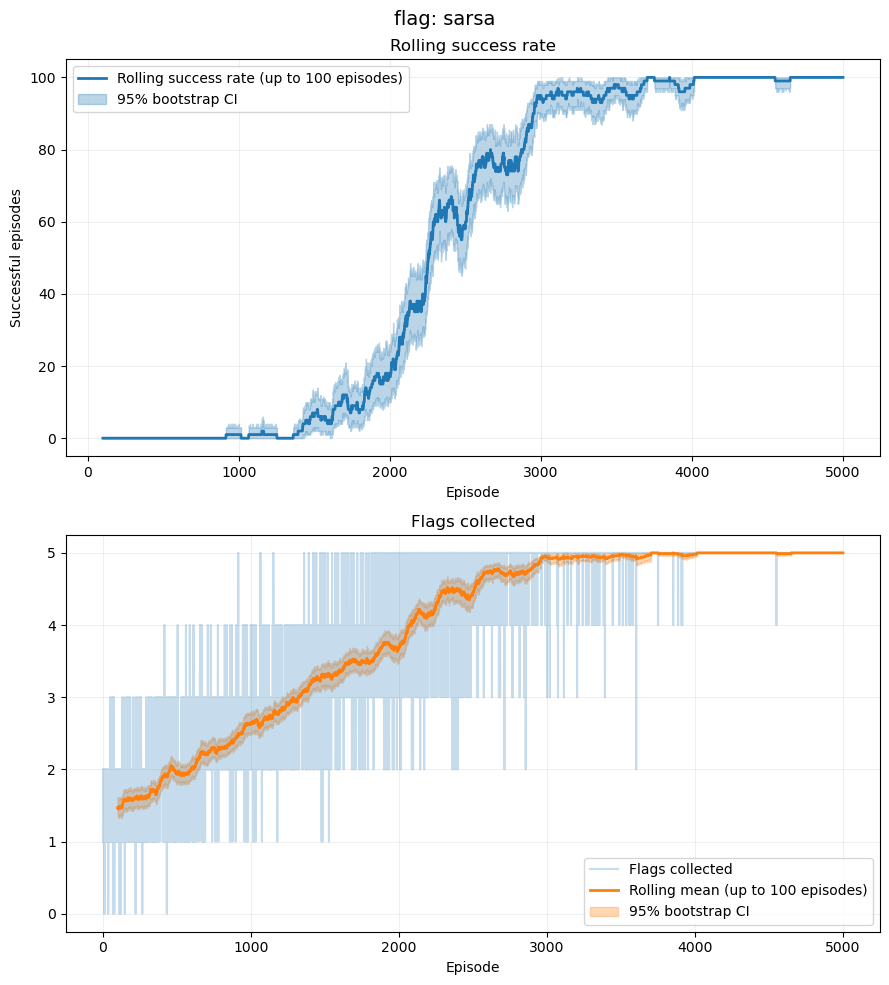

Salvato: c:\Users\39324\Desktop\NAML_RL_gym\artifacts\flag\bootstrap_plots\GridFlag_outcomes_sarsa_bootstrap.png


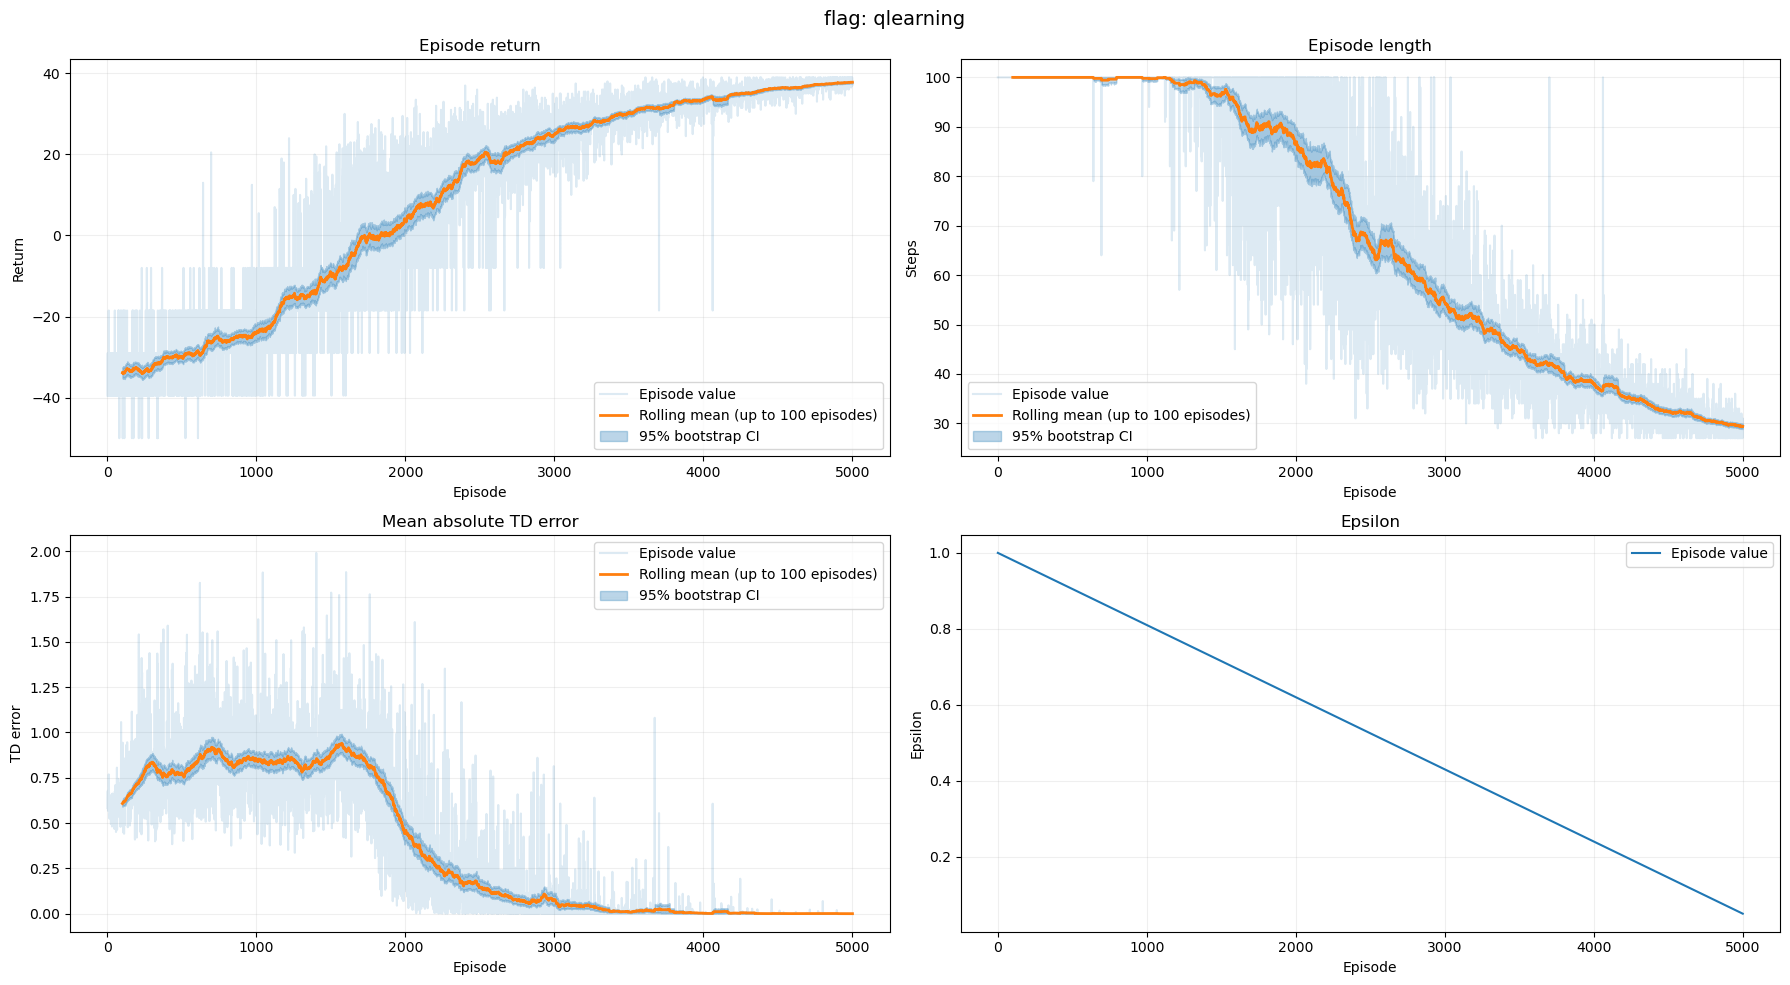

Salvato: c:\Users\39324\Desktop\NAML_RL_gym\artifacts\flag\bootstrap_plots\GridFlag_training_curves_qlearning_bootstrap.png


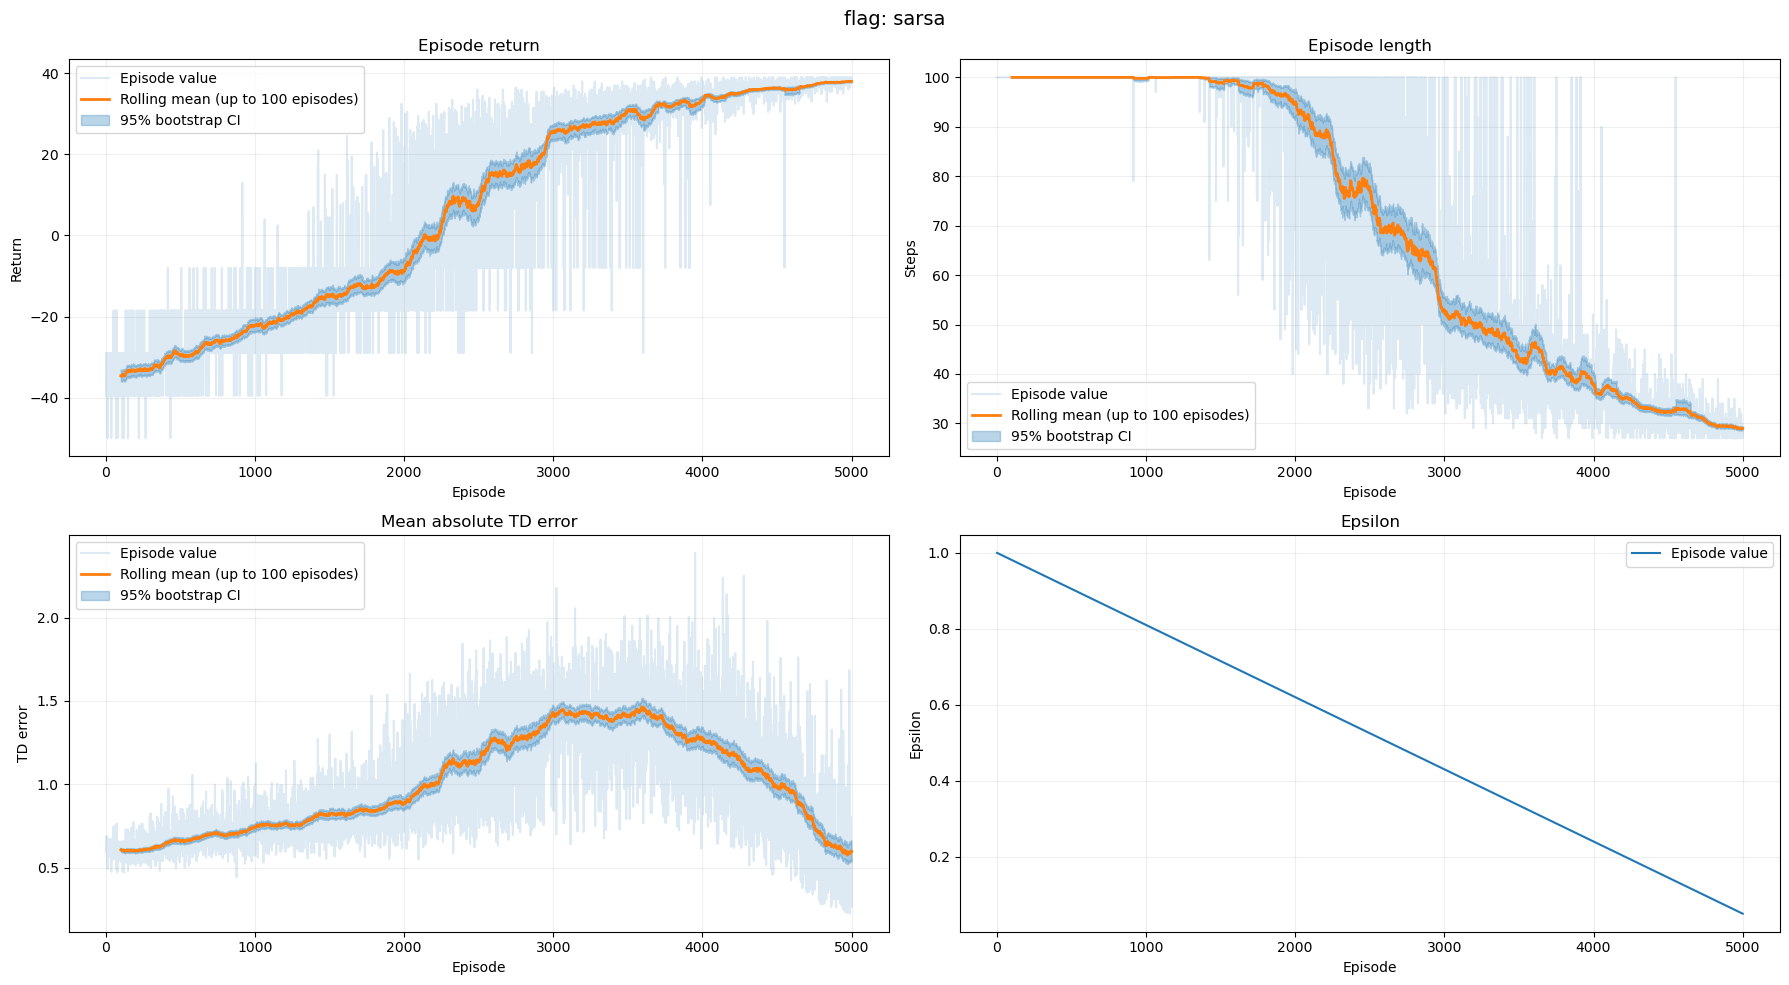

Salvato: c:\Users\39324\Desktop\NAML_RL_gym\artifacts\flag\bootstrap_plots\GridFlag_training_curves_sarsa_bootstrap.png


In [24]:
# ============================================================
# Grid Flag (Q-learning / SARSA): "outcomes" and "training curves"
# plots in BOOTSTRAP-CI version, read ONLY from metrics.csv.
# No training needed.
# ============================================================

from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ALGORITHM_LABELS = {"qlearning": "Q-learning", "sarsa": "SARSA"}
ENVIRONMENT = "flag"          # artifacts/<ENVIRONMENT>/<algorithm>/<run>/metrics.csv
COMPARISON_WINDOW = 100       # same default used in the cliff notebook

# ------------------------------------------------------------
# 1. Locate ROOT / OUTPUT_ROOT exactly like the notebooks do
# ------------------------------------------------------------

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "rl_project").is_dir())
OUTPUT_ROOT = ROOT / "artifacts"


# ------------------------------------------------------------
# 2. Find the latest completed run per algorithm (no training)
# ------------------------------------------------------------

def latest_run_dir(environment, algorithm, output_root=OUTPUT_ROOT):
    base = Path(output_root) / environment / algorithm
    candidates = [p for p in base.iterdir() if p.is_dir() and (p / "metrics.csv").exists()]
    if not candidates:
        raise FileNotFoundError(f"Nessuna run trovata in {base}")
    return sorted(candidates, key=lambda p: p.name)[0]

run_dirs = {
    "qlearning": latest_run_dir(ENVIRONMENT, "qlearning"),
    "sarsa": latest_run_dir(ENVIRONMENT, "sarsa"),
}
    #"artifacts\flag\sarsa\20260913T085951982917Z_seed0_d34cfb8b\metrics.csv

for algo, d in run_dirs.items():
    print(f"{ALGORITHM_LABELS[algo]}: {d}")


# ------------------------------------------------------------
# 3. Bootstrap band (identica a quella del notebook cliff, cell 14)
# ------------------------------------------------------------

def bootstrap_band(values, window=100, n_boot=300, ci=95, seed=0):
    """Bootstrap CI on a rolling window, from metrics.csv already on disk. No retraining."""
    rng = np.random.default_rng(seed)
    values = np.asarray(values, dtype=float)
    n = len(values)
    mean = np.full(n, np.nan)
    lo = np.full(n, np.nan)
    hi = np.full(n, np.nan)
    for i in range(window, n):
        w = values[i - window:i]
        idx = rng.integers(0, window, size=(n_boot, window))
        boot_means = w[idx].mean(axis=1)
        mean[i] = w.mean()
        lo[i], hi[i] = np.percentile(boot_means, [(100 - ci) / 2, 100 - (100 - ci) / 2])
    return mean, lo, hi


def load_metrics(run_dir):
    df = pd.read_csv(Path(run_dir) / "metrics.csv")
    df = df.sort_values("episode").reset_index(drop=True)
    return df


def find_column(columns, keywords):
    for c in columns:
        cl = c.lower()
        if any(k in cl for k in keywords):
            return c
    return None


out_dir = OUTPUT_ROOT / ENVIRONMENT / "bootstrap_plots"
out_dir.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 4. Per-algorithm "outcomes" figure: success rate + flags collected
# ------------------------------------------------------------

for algorithm, run_dir in run_dirs.items():
    df = load_metrics(run_dir)
    x = df["episode"].to_numpy()

    success_col = find_column(df.columns, ["success"])
    flags_col = find_column(df.columns, ["flag", "n_flags", "flags_collected"])

    n_panels = sum(c is not None for c in (success_col, flags_col))
    if n_panels == 0:
        print(f"[{ALGORITHM_LABELS[algorithm]}] Nessuna colonna success/flags trovata, salto outcomes.")
        continue

    fig, axes = plt.subplots(n_panels, 1, figsize=(9, 5 * n_panels))
    if n_panels == 1:
        axes = [axes]
    ax_iter = iter(axes)

    if success_col is not None:
        ax = next(ax_iter)
        success = df[success_col].to_numpy(dtype=float)
        mean, lo, hi = bootstrap_band(success, window=COMPARISON_WINDOW, n_boot=300)
        ax.plot(x, mean * 100, linewidth=2, color="tab:blue", label=f"Rolling success rate (up to {COMPARISON_WINDOW} episodes)")
        ax.fill_between(x, lo * 100, hi * 100, alpha=0.30, color="tab:blue", label="95% bootstrap CI")
        ax.set_title("Rolling success rate")
        ax.set_xlabel("Episode")
        ax.set_ylabel("Successful episodes")
        ax.set_ylim(-5, 105)
        ax.legend()
        ax.grid(alpha=0.2)

    if flags_col is not None:
        ax = next(ax_iter)
        flags = df[flags_col].to_numpy(dtype=float)
        mean, lo, hi = bootstrap_band(flags, window=COMPARISON_WINDOW, n_boot=300)
        ax.plot(x, flags, alpha=0.25, color="tab:blue", label="Flags collected")
        ax.plot(x, mean, linewidth=2, color="tab:orange", label=f"Rolling mean (up to {COMPARISON_WINDOW} episodes)")
        ax.fill_between(x, lo, hi, alpha=0.30, color="tab:orange", label="95% bootstrap CI")
        ax.set_title("Flags collected")
        ax.set_xlabel("Episode")
        ax.legend()
        ax.grid(alpha=0.2)

    fig.suptitle(f"flag: {algorithm}", fontsize=14)
    fig.tight_layout()
    save_path = out_dir / f"GridFlag_outcomes_{algorithm}_bootstrap.png"
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"Salvato: {save_path}")


# ------------------------------------------------------------
# 5. Per-algorithm "training curves" figure:
#    Episode return, Episode length, TD error, Epsilon
# ------------------------------------------------------------

PANEL_SPECS = [
    ("return", ["reward", "return"], "Episode return", "Return", True),
    ("length", ["length", "steps"], "Episode length", "Steps", True),
    ("td_error", ["td_error", "td error", "temporal"], "Mean absolute TD error", "TD error", True),
    ("epsilon", ["epsilon"], "Epsilon", "Epsilon", False),  # deterministic schedule, no CI needed
]

for algorithm, run_dir in run_dirs.items():
    df = load_metrics(run_dir)
    x = df["episode"].to_numpy()

    resolved = []
    for key, keywords, title, ylabel, use_bootstrap in PANEL_SPECS:
        col = find_column(df.columns, keywords)
        if col is not None:
            resolved.append((col, title, ylabel, use_bootstrap))

    if not resolved:
        print(f"[{ALGORITHM_LABELS[algorithm]}] Nessuna colonna riconosciuta, salto training curves.")
        continue

    n_panels = len(resolved)
    n_cols = 2
    n_rows = int(np.ceil(n_panels / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(9 * n_cols, 5 * n_rows))
    axes = np.atleast_1d(axes).flatten()

    for (col, title, ylabel, use_bootstrap), ax in zip(resolved, axes):
        values = df[col].to_numpy(dtype=float)
        if use_bootstrap:
            mean, lo, hi = bootstrap_band(values, window=COMPARISON_WINDOW, n_boot=300)
            ax.plot(x, values, alpha=0.15, color="tab:blue", label="Episode value")
            ax.plot(x, mean, linewidth=2, color="tab:orange", label=f"Rolling mean (up to {COMPARISON_WINDOW} episodes)")
            ax.fill_between(x, lo, hi, alpha=0.30, color="tab:blue", label="95% bootstrap CI")
        else:
            ax.plot(x, values, color="tab:blue", label="Episode value")
        ax.set_title(title)
        ax.set_xlabel("Episode")
        ax.set_ylabel(ylabel)
        ax.legend()
        ax.grid(alpha=0.2)

    # hide any unused subplot slots
    for ax in axes[len(resolved):]:
        ax.axis("off")

    fig.suptitle(f"flag: {algorithm}", fontsize=14)
    fig.tight_layout()
    save_path = out_dir / f"GridFlag_training_curves_{algorithm}_bootstrap.png"
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"Salvato: {save_path}")